# PCA-Based Relative Value Backtest

Systematic RV strategy on the USD SOFR swap curve using rolling PCA residuals,
OLS regression signals, traffic-light regime filtering, and dual MTM modes.

**References:**
- J.P. Morgan "RV on the EUR swap yield curve" (Apr 2021)
- Standard Chartered PCA residual heatmap approach

## Section 1: Imports & Configuration

In [5]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (12, 8),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import sys
sys.path.append("../../")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import datetime
import numpy as np
import pandas as pd
import pytz
from IPython.display import display

from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from TB.TimeseriesBuilder import TimeseriesBuilder
from TB.IRSwapsTB import IRSwapsTB
from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapValue import IRSwapValue

from BT.signals.regression_rv import RegressionRVConfig, rolling_regression
from BT.signals.regime_filter import RegimeFilterConfig, traffic_light
from BT.signals.rv_backtest import RVBacktestConfig, run_rv_backtest

In [17]:
def ou_half_life(series: pd.Series) -> float:
    """Estimate Ornstein-Uhlenbeck half-life via AR(1) regression.

    Fits: x(t) - x(t-1) = a + b * x(t-1) + eps
    Half-life = -ln(2) / ln(1 + b)

    Returns half-life in the same units as the series frequency (business days).
    """
    x = series.dropna().values
    if len(x) < 10:
        return np.nan
    dx = np.diff(x)
    x_lag = x[:-1]
    # OLS: dx = a + b * x_lag
    X = np.column_stack([np.ones(len(x_lag)), x_lag])
    try:
        beta = np.linalg.lstsq(X, dx, rcond=None)[0]
    except np.linalg.LinAlgError:
        return np.nan
    b = beta[1]
    if b >= 0:
        return np.inf  # not mean-reverting
    return -np.log(2) / np.log(1 + b)


def adf_test(series: pd.Series):
    """Run augmented Dickey-Fuller test on a series.

    Returns dict with keys: statistic, pvalue, half_life.
    """
    from statsmodels.tsa.stattools import adfuller

    clean = series.dropna()
    if len(clean) < 20:
        return {"statistic": np.nan, "pvalue": np.nan, "half_life": np.nan}
    result = adfuller(clean.values, autolag="AIC")
    return {
        "statistic": float(result[0]),
        "pvalue": float(result[1]),
        "half_life": ou_half_life(clean),
    }


In [18]:
config = {
    # --- Data ---
    "data_start": "2022-03-01",
    "data_end": "2026-03-21",
    # "tenors_spot": ["2Y", "3Y", "5Y", "7Y", "10Y", "15Y", "20Y", "30Y"],
    # "forward_tails": ["1Y", "2Y", "3Y", "5Y"],  # e.g. ["1Y", "2Y"] for forward-starting
    
	"forward_tails": ["2Y", "3Y", "5Y", "7Y", "10Y", "15Y", "20Y", "30Y"],
    "tenors_spot": ["1Y", "2Y", "3Y", "5Y"],  # e.g. ["1Y", "2Y"] for forward-starting

    # --- Fly definitions ---
    "fly_categories": {
        "standard_spot": [
            ("2Y", "5Y", "10Y"),
            ("3Y", "5Y", "7Y"),
            ("2Y", "5Y", "7Y"),
            ("5Y", "10Y", "30Y"),
            ("2Y", "3Y", "5Y"),
            ("5Y", "7Y", "10Y"),
            ("7Y", "10Y", "15Y"),
            ("10Y", "15Y", "20Y"),
            ("10Y", "20Y", "30Y"),
			("15Y", "20Y", "30Y"),
        ],
        "standard_1y_fwd": [
            ("1Yx2Y", "1Yx5Y", "1Yx10Y"),
            ("1Yx3Y", "1Yx5Y", "1Yx7Y"),
            ("1Yx2Y", "1Yx5Y", "1Yx7Y"),
            ("1Yx5Y", "1Yx10Y", "1Yx30Y"),
            ("1Yx2Y", "1Yx3Y", "1Yx5Y"),
            ("1Yx5Y", "1Yx7Y", "1Yx10Y"),
            ("1Yx7Y", "1Yx10Y", "1Yx15Y"),
            ("1Yx10Y", "1Yx15Y", "1Yx20Y"),
            ("1Yx10Y", "1Yx20Y", "1Yx30Y"),
			("1Yx15Y", "1Yx20Y", "1Yx30Y"),
        ],
		"standard_2y_fwd": [
            ("2Yx2Y", "2Yx5Y", "2Yx10Y"),
            ("2Yx3Y", "2Yx5Y", "2Yx7Y"),
            ("2Yx2Y", "2Yx5Y", "2Yx7Y"),
            ("2Yx5Y", "2Yx10Y", "2Yx30Y"),
            ("2Yx2Y", "2Yx3Y", "2Yx5Y"),
            ("2Yx5Y", "2Yx7Y", "2Yx10Y"),
            ("2Yx7Y", "2Yx10Y", "2Yx15Y"),
            ("2Yx10Y", "2Yx15Y", "2Yx20Y"),
            ("2Yx10Y", "2Yx20Y", "2Yx30Y"),
			("2Yx15Y", "2Yx20Y", "2Yx30Y"),
        ],
        "standard_3y_fwd": [
            ("3Yx2Y", "3Yx5Y", "3Yx10Y"),
            ("3Yx3Y", "3Yx5Y", "3Yx7Y"),
            ("3Yx2Y", "3Yx5Y", "3Yx7Y"),
            ("3Yx5Y", "3Yx10Y", "3Yx30Y"),
            ("3Yx2Y", "3Yx3Y", "3Yx5Y"),
            ("3Yx5Y", "3Yx7Y", "3Yx10Y"),
            ("3Yx7Y", "3Yx10Y", "3Yx15Y"),
            ("3Yx10Y", "3Yx15Y", "3Yx20Y"),
            ("3Yx10Y", "3Yx20Y", "3Yx30Y"),
			("3Yx15Y", "3Yx20Y", "3Yx30Y"),
        ],
		"standard_5y_fwd": [
            ("5Yx2Y", "5Yx5Y", "5Yx10Y"),
            ("5Yx3Y", "5Yx5Y", "5Yx7Y"),
            ("5Yx2Y", "5Yx5Y", "5Yx7Y"),
            ("5Yx5Y", "5Yx10Y", "5Yx30Y"),
            ("5Yx2Y", "5Yx3Y", "5Yx5Y"),
            ("5Yx5Y", "5Yx7Y", "5Yx10Y"),
            ("5Yx7Y", "5Yx10Y", "5Yx15Y"),
            ("5Yx10Y", "5Yx15Y", "5Yx20Y"),
            ("5Yx10Y", "5Yx20Y", "5Yx30Y"),
			("5Yx15Y", "5Yx20Y", "5Yx30Y"),
        ],
    },
    "enabled_categories": ["standard_spot", "standard_1y_fwd", "standard_2y_fwd", "standard_3y_fwd", "standard_5y_fwd"],

    # --- Signal ---
    "window_days": 126,
    "zscore_lookback_days": 126,

    # --- Regime filter ---
    "regime_filter_enabled": True,
    "regime_reference_fly": ("2Y", "5Y", "10Y"),
    "beta_vol_window_days": 120,
    "beta_vol_zscore_window_days": 120,
    "regime_threshold": 3.0,

    # --- Entry triggers ---
    "entry_min_rsq": 0.60,
    "entry_min_residual_bp": 4.0,
    "entry_min_zscore": 1.5,

    # --- Exit triggers ---
    "exit_mean_reversion": True,
    "exit_stop_loss_sd": 2.0,
    "exit_max_holding_days": 60,
    "exit_carry_adjusted": False,

    # --- Portfolio rules ---
    "max_concurrent_trades": 10,
    "no_duplicate_flies": True,

    # --- Costs ---
    "round_trip_cost_bp": 0.5,
    "min_profit_to_cost_ratio": 2.0,

    # --- MTM mode ---
    # "mtm_mode": "curve",  # "approximate" or "curve"
    "mtm_mode": "approximate",  # "approximate" or "curve"
}
print("Config loaded")

Config loaded


## Section 2: Data Loading

In [9]:
def load_rate_timeseries(config, curve_mdp, ts_builder):
    """Load historical swap rates for all tenors defined in config."""
    tz = pytz.timezone("America/New_York")
    start = datetime.datetime.strptime(config["data_start"], "%Y-%m-%d").replace(hour=17, tzinfo=tz)
    end = datetime.datetime.strptime(config["data_end"], "%Y-%m-%d").replace(hour=17, tzinfo=tz)

    # Spot tenors
    queries = [
        IRSwapQuery(curve="USD-SOFR-1D", tenor=t, value=IRSwapValue.RATE)
        for t in config["tenors_spot"]
    ]

    # Forward-starting tenors for each tail
    for tail in config["forward_tails"]:
        for spot_t in config["tenors_spot"]:
            fwd_tenor = f"{spot_t}x{tail}" if "x" not in spot_t else spot_t
            queries.append(
                IRSwapQuery(curve="USD-SOFR-1D", tenor=fwd_tenor, value=IRSwapValue.RATE)
            )

    # Build enabled fly tenors and ensure they're in the query set
    fly_tenors = set()
    for cat in config["enabled_categories"]:
        for fly in config["fly_categories"].get(cat, []):
            for t in fly:
                fly_tenors.add(t)

    for t in fly_tenors:
        if not any(q.tenor == t for q in queries):
            queries.append(
                IRSwapQuery(curve="USD-SOFR-1D", tenor=t, value=IRSwapValue.RATE)
            )

    router = {"IRS": IRSwapsTB(curve_mdp, show_tqdm=True)}
    df = ts_builder.get_timeseries(start=start, end=end, queries=queries, n_jobs=12, routers=router)
    return df

In [10]:
curve_mdp = IRSwapsMDP(source="ERIS_EOD_LIVE-RL_BASIC")
ts_builder = TimeseriesBuilder()
rates_df = load_rate_timeseries(config, curve_mdp, ts_builder)
rates_df

READING USD-SOFR-1D computed cache...:   0%|          | 0/41 [00:00<?, ?it/s]

READING USD-SOFR-1D curve analytics...:   0%|          | 0/1013 [00:00<?, ?it/s]

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

VECTOR PRICING USD-SOFR-1D IRS...:   0%|          | 0/7 [00:00<?, ?it/s]

WRITING USD-SOFR-1D computed cache...:   0%|          | 0/7 [00:00<?, ?it/s]

,USD-SOFR-1D 10Y OUTRIGHT RATE,USD-SOFR-1D 15Y OUTRIGHT RATE,USD-SOFR-1D 1Y OUTRIGHT RATE,USD-SOFR-1D 1Yx10Y OUTRIGHT RATE,USD-SOFR-1D 1Yx15Y OUTRIGHT RATE,USD-SOFR-1D 1Yx20Y OUTRIGHT RATE,USD-SOFR-1D 1Yx2Y OUTRIGHT RATE,USD-SOFR-1D 1Yx30Y OUTRIGHT RATE,USD-SOFR-1D 1Yx3Y OUTRIGHT RATE,USD-SOFR-1D 1Yx5Y OUTRIGHT RATE,...,USD-SOFR-1D 5Y OUTRIGHT RATE,USD-SOFR-1D 5Yx10Y OUTRIGHT RATE,USD-SOFR-1D 5Yx15Y OUTRIGHT RATE,USD-SOFR-1D 5Yx20Y OUTRIGHT RATE,USD-SOFR-1D 5Yx2Y OUTRIGHT RATE,USD-SOFR-1D 5Yx30Y OUTRIGHT RATE,USD-SOFR-1D 5Yx3Y OUTRIGHT RATE,USD-SOFR-1D 5Yx5Y OUTRIGHT RATE,USD-SOFR-1D 5Yx7Y OUTRIGHT RATE,USD-SOFR-1D 7Y OUTRIGHT RATE
Date,,,,,,,,,,,,,,,,,,,,,
2022-03-01,1.524872,1.613944,0.805859,1.629337,1.687360,1.699433,1.548539,1.628126,1.523402,1.529176,...,1.371775,1.750860,1.759711,1.714197,1.608907,1.585359,1.640002,1.690383,1.724471,1.437245
2022-03-02,1.698374,1.768208,1.015186,1.792674,1.835631,1.835037,1.807733,1.759106,1.763581,1.743721,...,1.594911,1.867211,1.868603,1.823137,1.749906,1.703636,1.772483,1.811141,1.838603,1.637437
2022-03-03,1.677810,1.743741,1.040548,1.768504,1.805853,1.807925,1.815401,1.727925,1.755793,1.712994,...,1.582680,1.835304,1.839537,1.794851,1.696014,1.663161,1.727298,1.780820,1.815074,1.613816
2022-03-04,1.558128,1.643686,1.014603,1.643661,1.702110,1.711788,1.690934,1.637760,1.623773,1.574899,...,1.469267,1.741907,1.754441,1.712263,1.553836,1.575772,1.587637,1.653566,1.707370,1.492683
2022-03-07,1.583396,1.628596,1.045464,1.658280,1.677990,1.672145,1.758297,1.584085,1.682206,1.627845,...,1.515828,1.692329,1.689735,1.640489,1.614933,1.504858,1.630318,1.656523,1.684726,1.543085
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-16,3.762166,3.976383,3.620246,3.834685,4.039384,4.117468,3.368975,4.078461,3.405521,3.532574,...,3.497551,4.296890,4.361613,4.329481,3.908713,4.183810,3.970892,4.081404,4.184363,3.604674
2026-03-17,3.749090,3.970984,3.616132,3.822604,4.034830,4.117309,3.352564,4.083866,3.386906,3.516334,...,3.482616,4.297415,4.367295,4.337932,3.897029,4.195580,3.957753,4.069987,4.179937,3.591085
2026-03-18,3.785344,3.995577,3.665348,3.854053,4.055680,4.132184,3.425263,4.091769,3.453589,3.572741,...,3.542702,4.298618,4.365260,4.332601,3.912497,4.187466,3.968900,4.077978,4.184537,3.639220


## Section 3: Signal Generation

In [11]:
def build_fly_rate_dfs(rates_df, config):
    """Extract [dates x 3] DataFrames for each fly from the full rate matrix."""
    fly_dfs = {}

    # Helper to find the right column for a tenor
    def find_col(tenor):
        for c in rates_df.columns:
            if tenor in c:
                return c
        return None

    for cat in config["enabled_categories"]:
        for fly_tuple in config["fly_categories"].get(cat, []):
            left, belly, right = fly_tuple
            c_left = find_col(left)
            c_belly = find_col(belly)
            c_right = find_col(right)
            if c_left and c_belly and c_right:
                fly_id = f"{left}/{belly}/{right}"
                fly_dfs[fly_id] = rates_df[[c_left, c_belly, c_right]].rename(
                    columns={c_left: "left", c_belly: "belly", c_right: "right"}
                ).dropna()
    return fly_dfs

fly_dfs = build_fly_rate_dfs(rates_df, config)
print(f"Built {len(fly_dfs)} fly DataFrames")

Built 50 fly DataFrames


In [12]:
reg_config = RegressionRVConfig(
    window_days=config["window_days"],
    zscore_lookback_days=config["zscore_lookback_days"],
)

all_residuals = {}
all_zscores = {}
all_rsq = {}
all_weights = {}
fly_categories_map = {}

for cat in config["enabled_categories"]:
    for fly_tuple in config["fly_categories"].get(cat, []):
        fly_id = "/".join(fly_tuple)
        if fly_id not in fly_dfs:
            continue

        df3 = fly_dfs[fly_id]
        # Regression method
        fly_50_50 = 0.5 * df3["left"] + 0.5 * df3["right"] - df3["belly"]
        body = df3["belly"]
        wing_curve = df3["right"] - df3["left"]
        reg_result = rolling_regression(fly_50_50, body, wing_curve, reg_config)
        all_residuals[fly_id] = reg_result.residuals
        all_zscores[fly_id] = reg_result.zscores
        all_rsq[fly_id] = reg_result.rsq
        # Convert hedge ratios to 3-column weights
        all_weights[fly_id] = pd.DataFrame({
            "left": reg_result.hedge_ratios["left_weight"],
            "belly": 1.0,
            "right": reg_result.hedge_ratios["right_weight"],
        }, index=df3.index)

        fly_categories_map[fly_id] = cat

print(f"Computed signals for {len(all_residuals)} flies")

Computed signals for 50 flies


## Section 4: Regime Filter (Traffic Light)

In [19]:
# Use reference fly for traffic light
ref_fly = "/".join(config["regime_reference_fly"])
if ref_fly in fly_dfs and config["regime_filter_enabled"]:
    ref_df = fly_dfs[ref_fly]
    ref_fly_50_50 = 0.5 * ref_df["left"] + 0.5 * ref_df["right"] - ref_df["belly"]
    ref_body = ref_df["belly"]
    ref_curve = ref_df["right"] - ref_df["left"]
    ref_reg = rolling_regression(ref_fly_50_50, ref_body, ref_curve, reg_config)

    tl_config = RegimeFilterConfig(
        beta_vol_window_days=config["beta_vol_window_days"],
        beta_vol_zscore_window_days=config["beta_vol_zscore_window_days"],
        threshold=config["regime_threshold"],
    )
    tl_result = traffic_light(ref_reg.betas_body, ref_reg.betas_curve, tl_config)
    regime_series = tl_result["regime"]
    print(f"Traffic light: {(regime_series == 'red').sum()} red days, {(regime_series == 'green').sum()} green days")
else:
    regime_series = pd.Series("green", index=rates_df.index)
    print("Regime filter disabled — all green")

Traffic light: 146 red days, 623 green days


## Section 5: Backtest Execution

In [20]:
bt_config = RVBacktestConfig(
    mtm_mode=config.get("mtm_mode", "approximate"),
    entry_min_rsq=config["entry_min_rsq"],
    entry_min_residual_bp=config["entry_min_residual_bp"],
    entry_min_zscore=config["entry_min_zscore"],
    exit_mean_reversion=config["exit_mean_reversion"],
    exit_stop_loss_sd=config["exit_stop_loss_sd"],
    exit_max_holding_days=config["exit_max_holding_days"],
    exit_carry_adjusted=config["exit_carry_adjusted"],
    max_concurrent_trades=config["max_concurrent_trades"],
    no_duplicate_flies=config["no_duplicate_flies"],
    round_trip_cost_bp=config["round_trip_cost_bp"],
    min_profit_to_cost_ratio=config["min_profit_to_cost_ratio"],
)

# Optional: load curves for "curve" mode
curves = None
build_pkg_fn = None
if config.get("mtm_mode") == "curve":
    print("Loading curves for full MTM mode...")
    import pytz
    tz = pytz.timezone("America/New_York")
    timestamps = [d.date() if hasattr(d, 'date') else d for d in rates_df.index]
    curve_map = curve_mdp.bulk_get_data({
        "curve_name": "USD-SOFR-1D",
        "timestamps": sorted(set(timestamps)),
        "n_jobs": 12,
    })
    curves = curve_map

    def _build_package(curve, fly_id, weights, direction):
        tenors = fly_id.split("/")
        pkg = []
        for j, t in enumerate(tenors):
            bpv = weights[j] * direction * (1 if j == 1 else -1)
            leg = curve.build_irswap(tenor=t, bpv=bpv * 1000)  # 1k/bp base
            pkg.append(leg)
        entry_npv = sum(curve.npv(leg) for leg in pkg)
        return pkg, entry_npv

    build_pkg_fn = _build_package
    print(f"Loaded {len(curve_map)} curves")

result = run_rv_backtest(
    residuals=all_residuals,
    zscores=all_zscores,
    rsq=all_rsq,
    weights=all_weights,
    rates=fly_dfs,
    regime=regime_series,
    fly_categories=fly_categories_map,
    config=bt_config,
    curves=curves,
    build_package_fn=build_pkg_fn,
)

print(f"Trades: {result.metrics['n_trades']}, Hit rate: {result.metrics['hit_rate']:.1%}, "
      f"Sharpe: {result.metrics['sharpe']:.2f}, Max DD: {result.metrics['max_drawdown_bp']:.1f}bp")

Trades: 412, Hit rate: 56.8%, Sharpe: 0.78, Max DD: -45799.1bp


## Section 6: Analytics

In [21]:
# Per-trade DataFrame
trade_df = pd.DataFrame([{
    "fly_id": t.fly_id,
    "category": t.category,
    "entry_date": t.entry_date,
    "exit_date": t.exit_date,
    "exit_reason": t.exit_reason,
    "entry_zscore": t.entry_zscore,
    "entry_residual_bp": t.entry_residual * 10_000,
    "pnl_bp": t.realized_pnl,
    "carry_bp": t.carry_bp,
    "holding_days": (len(pd.bdate_range(t.entry_date, t.exit_date)) - 1) if t.exit_date else 0,
    "direction": t.direction,
} for t in result.trades])
if len(trade_df) > 0:
    display(trade_df.describe())
    print("\nBy category:")
    display(trade_df.groupby("category")["pnl_bp"].agg(["count", "mean", "std", "sum"]))
    print("\nBy exit reason:")
    display(trade_df.groupby("exit_reason")["pnl_bp"].agg(["count", "mean", "sum"]))

,entry_zscore,entry_residual_bp,pnl_bp,carry_bp,holding_days,direction
count,412.000000,412.000000,412.000000,412.0,412.000000,412.000000
mean,0.126002,1.638582,438.397951,0.0,14.308252,-0.087379
std,1.953621,121.511057,4002.317119,0.0,16.952047,0.997386
min,-5.289062,-766.327099,-15176.974632,0.0,0.000000,-1.000000
25%,-1.740564,-44.472191,-1855.718718,0.0,3.000000,-1.000000
50%,1.529853,22.322119,387.511989,0.0,7.000000,-1.000000
75%,1.740654,51.247703,2355.223300,0.0,19.250000,1.000000
max,4.140770,573.038947,15024.782603,0.0,61.000000,1.000000



By category:


,count,mean,std,sum
category,,,,
standard_1y_fwd,120,733.863758,4082.266147,88063.650991
standard_2y_fwd,79,217.623421,2988.657872,17192.250244
standard_3y_fwd,59,-120.849365,3217.552001,-7130.112516
standard_5y_fwd,44,147.364428,3900.270655,6484.034840
standard_spot,110,691.001202,4889.323020,76010.132252



By exit reason:


,count,mean,sum
exit_reason,,,
end_of_backtest,7,-1042.690364,-7298.832545
max_hold,25,-186.707593,-4667.689830
mean_reversion,368,500.593573,184218.434865
stop_loss,12,697.336943,8368.043321


In [22]:
# Stationarity tests
stationarity_results = []
for fly_id, res in all_residuals.items():
    clean = res.dropna()
    if len(clean) > 50:
        adf = adf_test(clean)
        stationarity_results.append({
            "fly_id": fly_id,
            "adf_stat": adf["statistic"],
            "adf_pvalue": adf["pvalue"],
            "half_life_days": adf["half_life"],
            "stationary": adf["pvalue"] < 0.05,
        })
stationarity_df = pd.DataFrame(stationarity_results)
display(stationarity_df)

,fly_id,adf_stat,adf_pvalue,half_life_days,stationary
0,2Y/5Y/10Y,-4.262728,5.150705e-04,9.137225,True
1,3Y/5Y/7Y,-3.919490,1.896005e-03,10.814921,True
2,2Y/5Y/7Y,-4.091593,9.999837e-04,12.279088,True
3,5Y/10Y/30Y,-5.594777,1.304540e-06,7.628616,True
4,2Y/3Y/5Y,-5.060080,1.685536e-05,12.524683,True
5,5Y/7Y/10Y,-3.087166,2.751767e-02,24.114452,True
6,7Y/10Y/15Y,-5.294033,5.633667e-06,11.002378,True
7,10Y/15Y/20Y,-2.557579,1.020855e-01,6.826330,False
8,10Y/20Y/30Y,-4.476313,2.169549e-04,9.591903,True
9,15Y/20Y/30Y,-4.363892,3.436900e-04,10.113692,True


In [23]:
# Parameter sensitivity grid (JPM Exhibit 7)
from itertools import product as itertools_product

rsq_thresholds = [0.60, 0.80]
residual_thresholds = [2.0, 3.0, 4.0]
zscore_thresholds = [1.5, 2.0]

sensitivity_results = []
for rsq_t, res_t, zs_t in itertools_product(rsq_thresholds, residual_thresholds, zscore_thresholds):
    test_config = RVBacktestConfig(
        mtm_mode="approximate",
        entry_min_rsq=rsq_t,
        entry_min_residual_bp=res_t,
        entry_min_zscore=zs_t,
        exit_mean_reversion=config["exit_mean_reversion"],
        exit_stop_loss_sd=config["exit_stop_loss_sd"],
        exit_max_holding_days=config["exit_max_holding_days"],
        round_trip_cost_bp=config["round_trip_cost_bp"],
    )
    r = run_rv_backtest(
        residuals=all_residuals, zscores=all_zscores, rsq=all_rsq,
        weights=all_weights, rates=fly_dfs, regime=regime_series,
        fly_categories=fly_categories_map, config=test_config,
    )
    sensitivity_results.append({
        "R²": rsq_t, "Residual_bp": res_t, "Z-score": zs_t,
        **r.metrics,
    })

sensitivity_df = pd.DataFrame(sensitivity_results)
display(sensitivity_df.style.format({
    "sharpe": "{:.2f}", "hit_rate": "{:.1%}", "avg_pnl_bp": "{:.2f}",
    "max_drawdown_bp": "{:.1f}", "total_pnl_bp": "{:.1f}",
}))

,R²,Residual_bp,Z-score,total_pnl_bp,n_trades,n_completed,hit_rate,avg_pnl_bp,sharpe,max_drawdown_bp,avg_holding_days
0,0.600000,2.000000,1.500000,262203.5,825,825,54.9%,317.32,0.69,-87765.5,12.448485
1,0.600000,2.000000,2.000000,93951.8,415,415,57.8%,225.89,0.32,-92154.0,16.125301
2,0.600000,3.000000,1.500000,263691.0,822,822,54.9%,320.29,0.69,-87765.5,12.453771
3,0.600000,3.000000,2.000000,93951.8,415,415,57.8%,225.89,0.32,-92154.0,16.125301
4,0.600000,4.000000,1.500000,266180.9,814,814,55.2%,326.50,0.70,-87765.5,12.563882
5,0.600000,4.000000,2.000000,93951.8,415,415,57.8%,225.89,0.32,-92154.0,16.125301
6,0.800000,2.000000,1.500000,275648.9,516,516,58.1%,533.70,0.99,-58617.9,13.486434
7,0.800000,2.000000,2.000000,126578.9,250,250,59.6%,505.82,0.62,-55663.5,18.472000
8,0.800000,3.000000,1.500000,279902.4,514,514,58.2%,544.06,1.00,-58617.9,13.476654
9,0.800000,3.000000,2.000000,126578.9,250,250,59.6%,505.82,0.62,-55663.5,18.472000


## Section 7: Visualization

In [24]:
def _contiguous_regions(mask):
    """Yield (start, end) tuples for contiguous True regions in a boolean Series."""
    regions = []
    in_region = False
    start = None
    for dt, val in mask.items():
        if val and not in_region:
            start = dt
            in_region = True
        elif not val and in_region:
            regions.append((start, dt))
            in_region = False
    if in_region:
        regions.append((start, mask.index[-1]))
    return regions

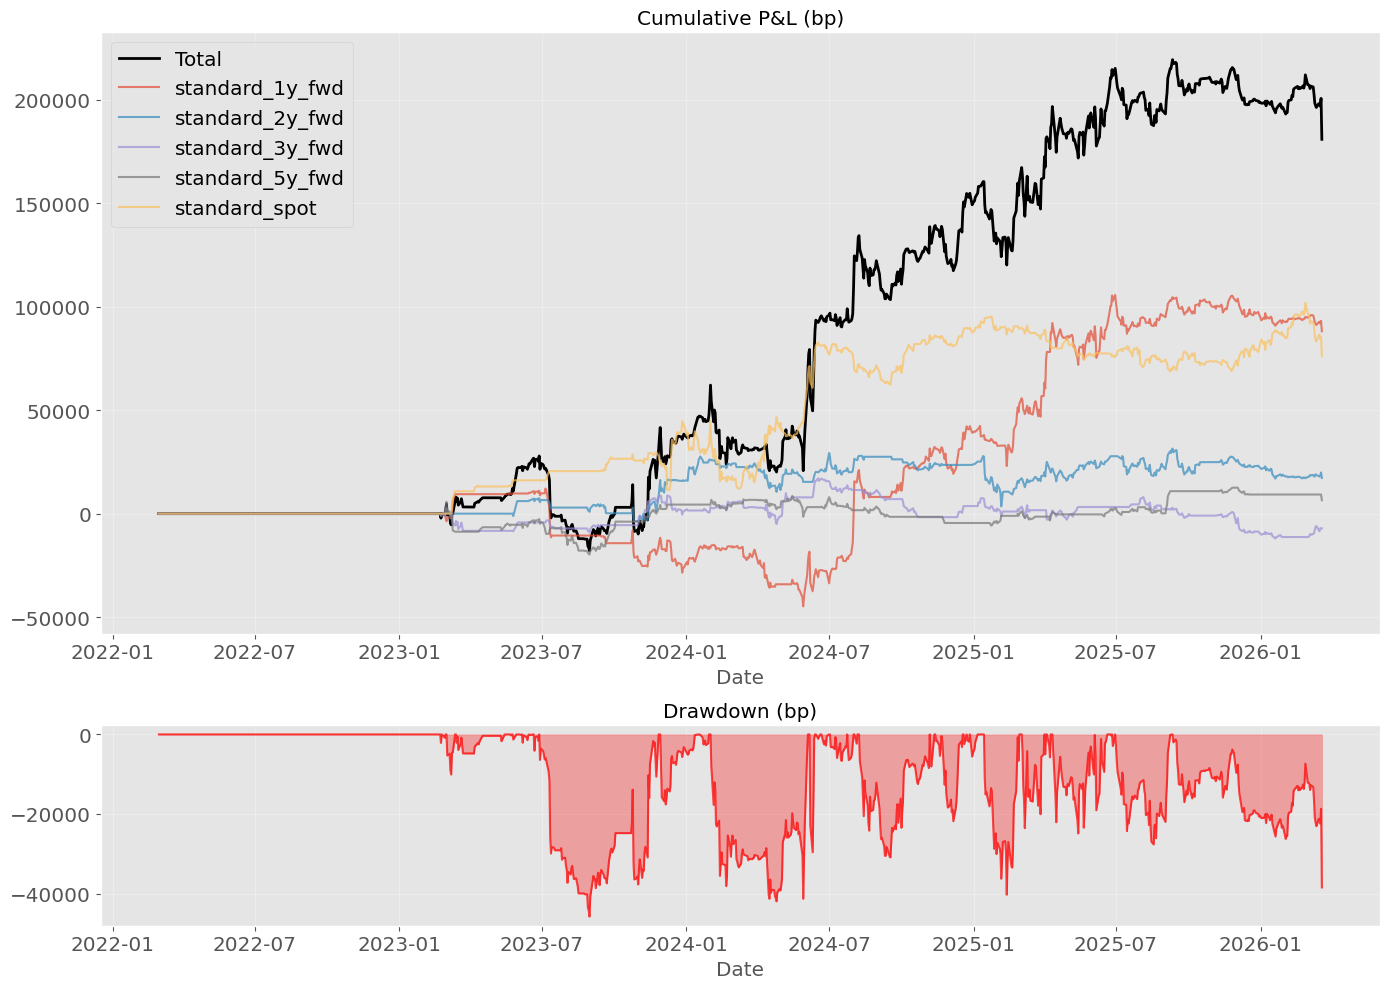

In [25]:
# Cumulative P&L + Drawdown
fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={"height_ratios": [3, 1]})

# Cumulative P&L by category
ax = axes[0]
result.cumulative_pnl.plot(ax=ax, label="Total", linewidth=2, color="black")
for cat in result.daily_pnl_by_category.columns:
    result.daily_pnl_by_category[cat].cumsum().plot(ax=ax, label=cat, alpha=0.7)
ax.set_title("Cumulative P&L (bp)")
ax.legend()
ax.grid(True, alpha=0.3)

# Drawdown
ax2 = axes[1]
dd = result.cumulative_pnl - result.cumulative_pnl.cummax()
dd.plot(ax=ax2, color="red", alpha=0.7)
ax2.fill_between(dd.index, dd.values, 0, alpha=0.3, color="red")
ax2.set_title("Drawdown (bp)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

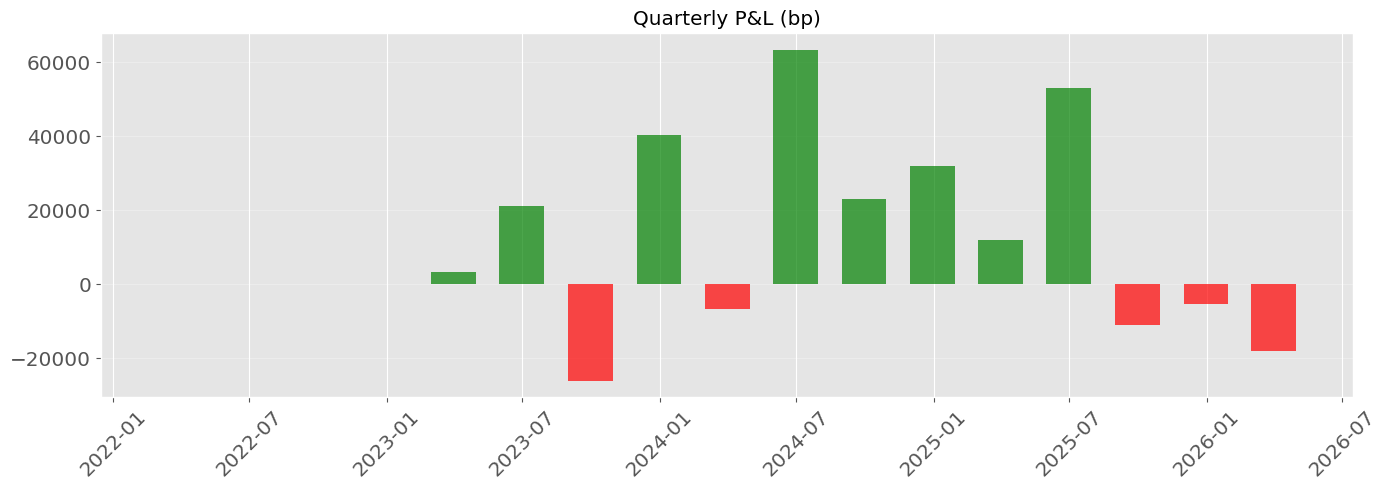

In [26]:
# Quarterly P&L bar chart (JPM Exhibit 5)
# quarterly_pnl = result.daily_pnl.resample("QE").sum()
daily_pnl_ts = result.daily_pnl.copy()
daily_pnl_ts.index = pd.DatetimeIndex(daily_pnl_ts.index)
quarterly_pnl = daily_pnl_ts.resample("QE").sum()
colors = ["green" if x >= 0 else "red" for x in quarterly_pnl.values]
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(quarterly_pnl.index, quarterly_pnl.values, width=60, color=colors, alpha=0.7)
ax.set_title("Quarterly P&L (bp)")
ax.grid(True, alpha=0.3, axis="y")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

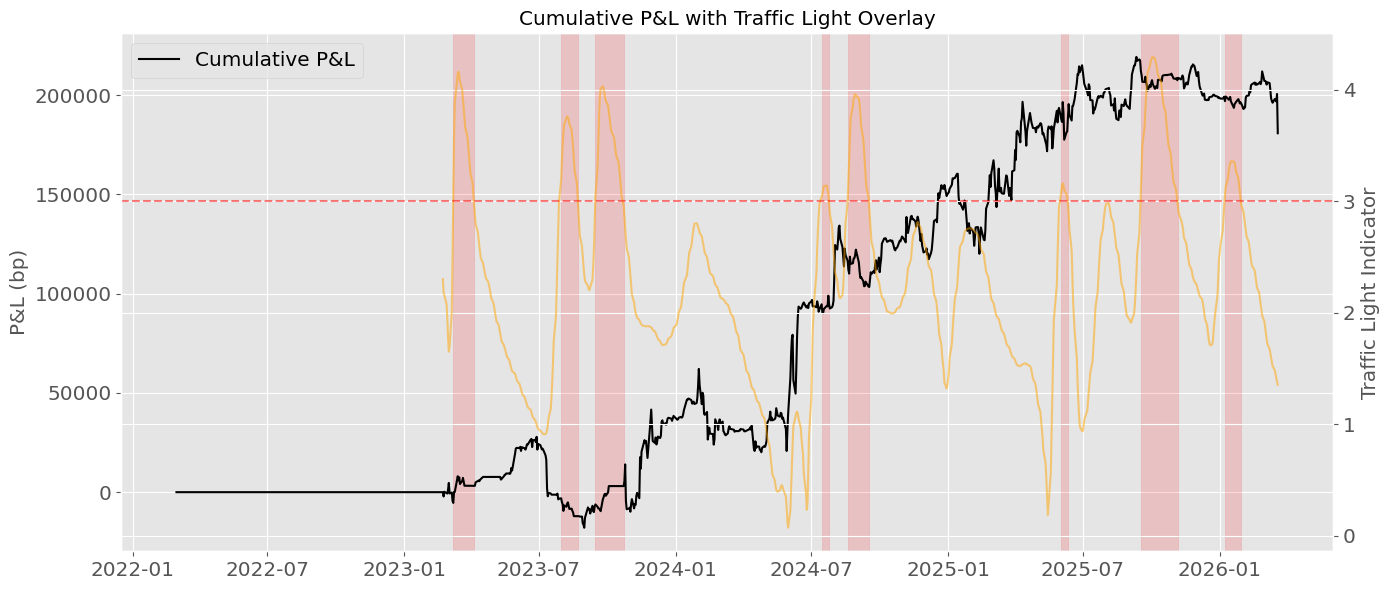

In [27]:
# Traffic light overlay
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(result.cumulative_pnl.index, result.cumulative_pnl.values, color="black", label="Cumulative P&L")
ax1.set_ylabel("P&L (bp)")

ax2 = ax1.twinx()
tl_indicator = tl_result["indicator"] if config["regime_filter_enabled"] else pd.Series()
if len(tl_indicator) > 0:
    ax2.plot(tl_indicator.index, tl_indicator.values, color="orange", alpha=0.5, label="Traffic Light")
    ax2.axhline(y=config["regime_threshold"], color="red", linestyle="--", alpha=0.5)
    # Shade red periods
    red_mask = tl_result["regime"] == "red"
    for start, end in _contiguous_regions(red_mask):
        ax1.axvspan(start, end, alpha=0.15, color="red")
    ax2.set_ylabel("Traffic Light Indicator")

ax1.legend(loc="upper left")
ax1.set_title("Cumulative P&L with Traffic Light Overlay")
plt.tight_layout()
plt.show()

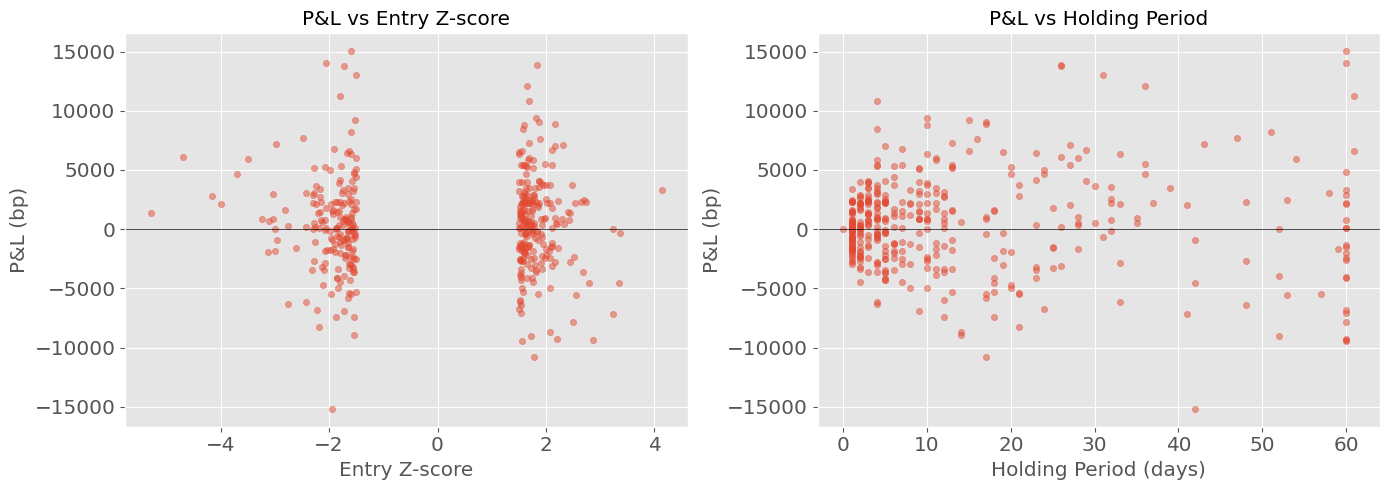

In [28]:
# Per-trade scatter
if len(trade_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(trade_df["entry_zscore"], trade_df["pnl_bp"], alpha=0.5, s=20)
    axes[0].axhline(y=0, color="black", linewidth=0.5)
    axes[0].set_xlabel("Entry Z-score")
    axes[0].set_ylabel("P&L (bp)")
    axes[0].set_title("P&L vs Entry Z-score")

    axes[1].scatter(trade_df["holding_days"], trade_df["pnl_bp"], alpha=0.5, s=20)
    axes[1].axhline(y=0, color="black", linewidth=0.5)
    axes[1].set_xlabel("Holding Period (days)")
    axes[1].set_ylabel("P&L (bp)")
    axes[1].set_title("P&L vs Holding Period")

    plt.tight_layout()
    plt.show()

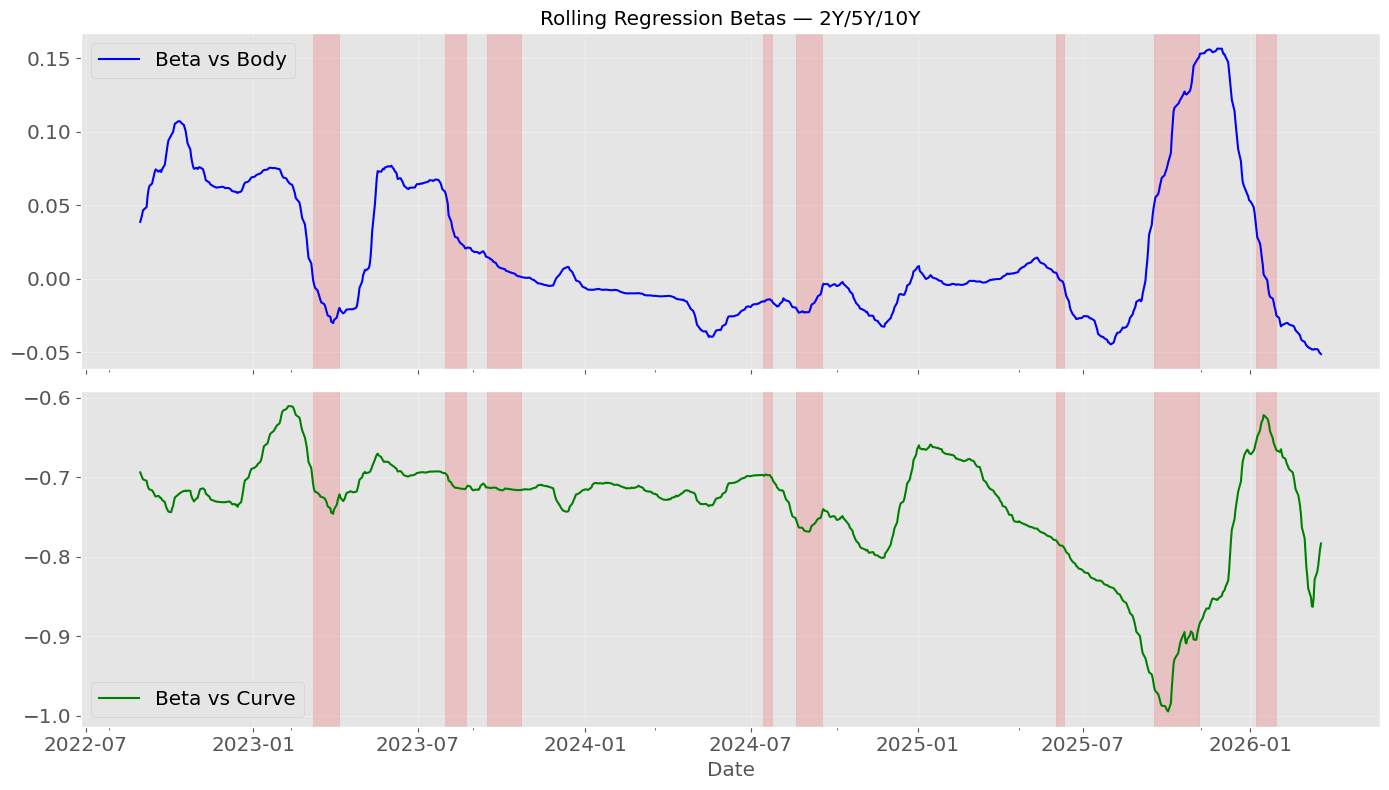

In [29]:
# Rolling beta charts
if config["regime_filter_enabled"] and ref_fly in fly_dfs:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    ref_reg.betas_body.dropna().plot(ax=axes[0], label="Beta vs Body", color="blue")
    axes[0].set_title(f"Rolling Regression Betas — {ref_fly}")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    ref_reg.betas_curve.dropna().plot(ax=axes[1], label="Beta vs Curve", color="green")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Shade red periods
    red_mask = tl_result["regime"] == "red"
    for ax in axes:
        for start, end in _contiguous_regions(red_mask):
            ax.axvspan(start, end, alpha=0.15, color="red")

    plt.tight_layout()
    plt.show()